# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [65]:
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# Load Dataset

In [3]:
df=pd.read_csv("car_prediction_data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


# Dataset Shape

In [6]:
df.shape

(301, 9)

In [7]:
print("No. of Rows : ",df.shape[0])

No. of Rows :  301


In [8]:
print("No. of Columns : ",df.shape[1])

No. of Columns :  9


# Dataset Statistical Information

In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# NUll Value Checking

In [10]:
df.isnull()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
296,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

There is no null values in the dataset 

# Check Duplicate Values

In [12]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool

In [13]:
df.duplicated().sum()

np.int64(2)

There is 2 duplicate rows

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)


# Standardize Categorical Values

In [16]:
df.sample(10)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
168,Honda CB Trigger,2013,0.42,0.730,12000,Petrol,Individual,Manual,0
142,Yamaha FZ v 2.0,2015,0.60,0.840,29000,Petrol,Individual,Manual,0
101,UM Renegade Mojave,2017,1.70,1.820,1400,Petrol,Individual,Manual,0
150,TVS Apache RTR 180,2011,0.50,0.826,6000,Petrol,Individual,Manual,0
227,i10,2011,2.55,4.430,57000,Petrol,Dealer,Manual,0
38,alto k10,2016,3.00,3.760,10079,Petrol,Dealer,Manual,0
257,city,2015,8.50,13.600,40324,Petrol,Dealer,Manual,0
268,brio,2017,4.80,5.800,19000,Petrol,Dealer,Manual,0
133,Bajaj Avenger 220,2016,0.72,0.950,500,Petrol,Individual,Manual,0
298,city,2009,3.35,11.000,87934,Petrol,Dealer,Manual,0


In [17]:
df.columns.values

<StringArray>
[     'Car_Name',          'Year', 'Selling_Price', 'Present_Price',
    'Kms_Driven',     'Fuel_Type',   'Seller_Type',  'Transmission',
         'Owner']
Length: 9, dtype: str

In [18]:
df["Seller_Type"].unique()

<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str

In [19]:
df["Fuel_Type"].unique()

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str

In [20]:
df["Transmission"].unique()

<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str

In [21]:
#Standardize Categorical Values
df["Seller_Type"]=df["Seller_Type"].str.title()
df["Fuel_Type"]=df["Fuel_Type"].str.title()
df["Transmission"]=df["Transmission"].str.title()

# Feature Engineering

### Calculate Car Age

In [22]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [23]:
current_year=2026

df["Car_Age"]=current_year-df["Year"]

In [24]:
df.sample(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
28,alto k10,2010,1.95,3.95,44542,Petrol,Dealer,Manual,0,16
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,9
258,city,2015,8.40,13.60,25000,Petrol,Dealer,Manual,0,11
143,Yamaha FZ v 2.0,2016,0.60,0.84,25000,Petrol,Individual,Manual,0,10
111,Royal Enfield Thunder 350,2016,1.15,1.50,8700,Petrol,Individual,Manual,0,10


# Extract Brand

But if you are using car_prediction_data.csv

If your dataset doesn't have a Car_Name column, you cannot perform this exact feature engineering.

Instead:

If there is already a Brand column, use it directly.
If there is only a Model column (e.g., "Swift", "Creta"), you cannot reliably determine the brand unless you have a separate mapping.
Do not invent or guess the brand.

In [25]:
df["Car_Name"].unique()

<StringArray>
[                     'ritz',                       'sx4',
                      'ciaz',                   'wagon r',
                     'swift',             'vitara brezza',
                   's cross',                  'alto 800',
                    'ertiga',                     'dzire',
                  'alto k10',                     'ignis',
                       '800',                    'baleno',
                      'omni',                  'fortuner',
                    'innova',             'corolla altis',
               'etios cross',                   'etios g',
                'etios liva',                   'corolla',
                  'etios gd',                     'camry',
              'land cruiser', 'Royal Enfield Thunder 500',
        'UM Renegade Mojave',                 'KTM RC200',
         'Bajaj Dominar 400', 'Royal Enfield Classic 350',
                 'KTM RC390',            'Hyosung GT250R',
 'Royal Enfield Thunder 350',             

# Exploratory Data Analysis (EDA)

## Distribution of selling prices

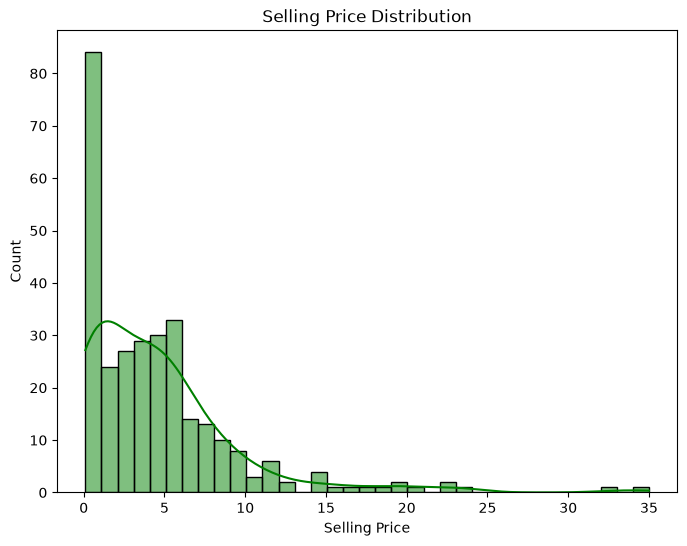

In [26]:
plt.figure(figsize=(8,6))
sns.histplot(df,x="Selling_Price",color="g",kde=True,bins=35)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

## Fuel Type vs Selling Price

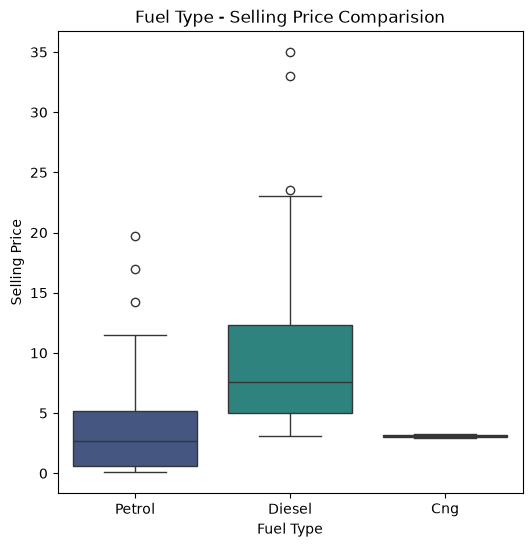

In [27]:
plt.figure(figsize=(6,6))
sns.boxplot(x=df["Fuel_Type"],y=df["Selling_Price"],hue=df["Fuel_Type"],palette="viridis")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.title("Fuel Type - Selling Price Comparision")
plt.show()

## Price vs. Car age (scatter plot)

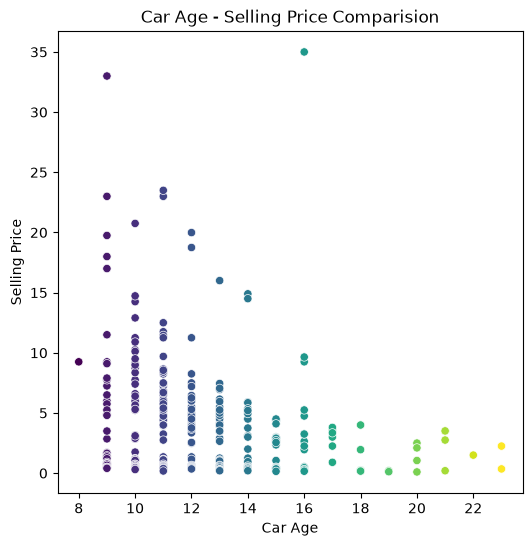

In [28]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=df["Car_Age"],y=df["Selling_Price"],hue=df["Car_Age"],palette="viridis",legend=False)
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age - Selling Price Comparision")
plt.show()

## Transmission vs Selling Price

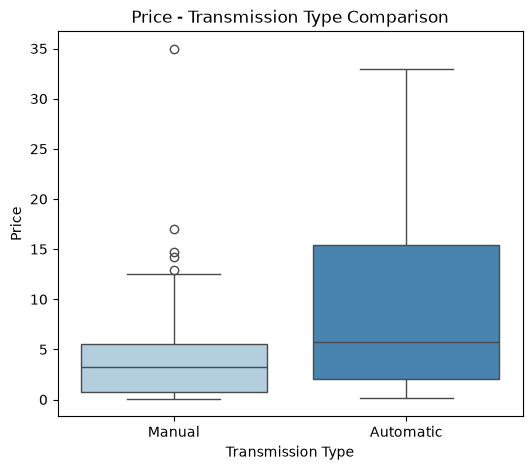

In [29]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df["Transmission"],y=df["Selling_Price"],hue=df["Transmission"],palette="Blues")
plt.xlabel("Transmission Type")
plt.ylabel("Price")
plt.title("Price - Transmission Type Comparison")
plt.show()

# Encode Categorical Variables

#### Categorical Columns

In [30]:
categorical_cols=df.select_dtypes(include=["object","string"]).columns

In [31]:
categorical_cols

Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='str')

#### Numeric Columns

In [32]:
numeric_cols=df.select_dtypes(exclude=["object","string"]).columns

In [33]:
numeric_cols

Index(['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner',
       'Car_Age'],
      dtype='str')

In [34]:
le = LabelEncoder()

In [35]:
for col in categorical_cols[1:]:
    df[col] = le.fit_transform(df[col])


In [36]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,2,0,1,0,12
1,sx4,2013,4.75,9.54,43000,1,0,1,0,13
2,ciaz,2017,7.25,9.85,6900,2,0,1,0,9
3,wagon r,2011,2.85,4.15,5200,2,0,1,0,15
4,swift,2014,4.60,6.87,42450,1,0,1,0,12


# Correlation Heatmap 

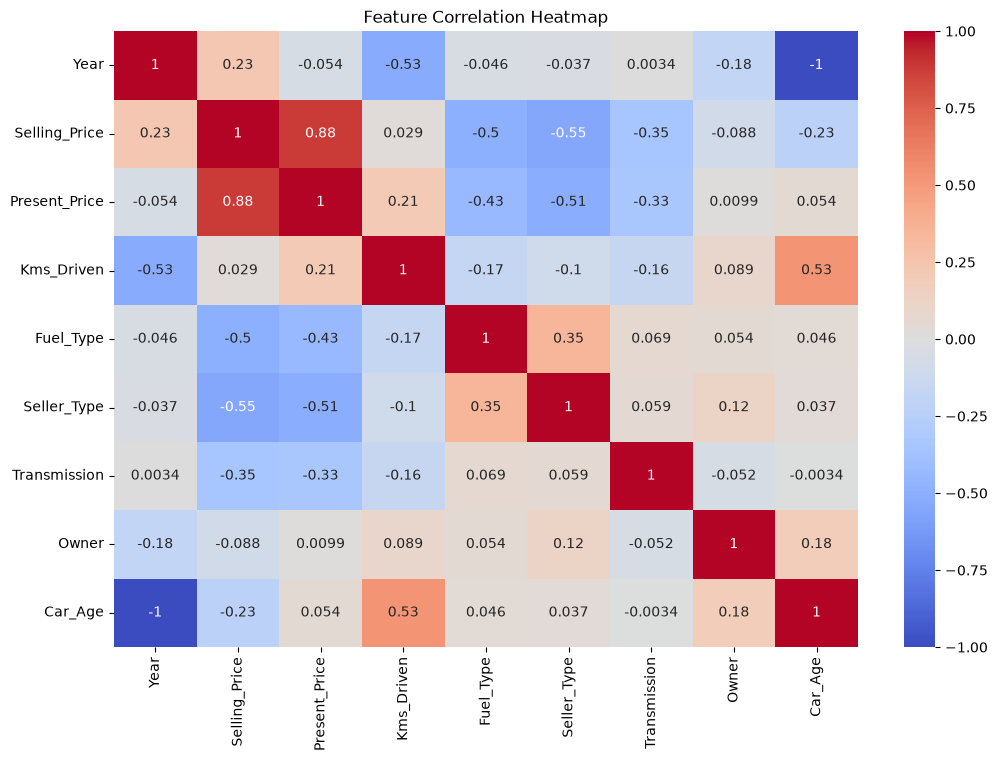

In [37]:
plt.figure(figsize=(12,8))

sns.heatmap(df.drop("Car_Name",axis=1).corr(),
           annot=True,
           cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

#### Separate Feature

In [38]:
x=df.drop(["Selling_Price","Car_Name"],axis=1)

In [39]:
y=df["Selling_Price"]

In [40]:
x

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,2014,5.59,27000,2,0,1,0,12
1,2013,9.54,43000,1,0,1,0,13
2,2017,9.85,6900,2,0,1,0,9
3,2011,4.15,5200,2,0,1,0,15
4,2014,6.87,42450,1,0,1,0,12
...,...,...,...,...,...,...,...,...
296,2016,11.60,33988,1,0,1,0,10
297,2015,5.90,60000,2,0,1,0,11
298,2009,11.00,87934,2,0,1,0,17
299,2017,12.50,9000,1,0,1,0,9


In [41]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 299, dtype: float64

## Train Test Split

In [42]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42)

In [43]:
x_train.shape

(239, 8)

In [44]:
x_test.shape

(60, 8)

In [45]:
y_train.shape

(239,)

In [46]:
y_test.shape

(60,)

# Model 1 - Linear Regression

In [51]:
lr=LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.17, 0.44,-0. ,...,-1.58, 0.7 ,-0.17]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Year','Present_Price','Kms_Driven',...,'Transmission','Owner','Car_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-337.7
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [52]:
pred_lr=lr.predict(x_test)

### Evaluate Linear Regression

In [54]:
# MAE
mae=mean_absolute_error(y_test,pred_lr,)
print("Mean Absolute Error : ",mae)


Mean Absolute Error :  1.5410718122837772


In [56]:
# RMSE

rsme=np.sqrt(mean_squared_error(y_test,pred_lr))

print("Root Mean Square Error : ",rsme)

Root Mean Square Error :  2.5832416547494237


In [57]:
# R2

r2=r2_score(y_test,pred_lr)

print("R2 Score : ",r2)

R2 Score :  0.7410829335729635


# Model 2 - Random Forest

In [66]:
rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [67]:
pred_rf=rf.predict(x_test)

### Evaluate Random Forest Regression

In [68]:
# MAE
mae=mean_absolute_error(y_test,pred_rf)
print("Mean Absolute Error : ",mae)

Mean Absolute Error :  1.563293333333334


In [69]:
# RMSE
rmse=np.sqrt(mean_squared_error(y_test,pred_rf))
print("Root Mean Square Error : ",rmse)


Root Mean Square Error :  3.8293683776831924


In [72]:
# R2 Score

r2=r2_score(y_test,pred_rf)
print("R2 Score :  ",r2)

R2 Score :   0.4310358523665523


# Compare Models

# Feature Importance

In [99]:
importance=pd.Series(
    abs(lr.coef_),
    index=x.columns
)

In [100]:
importance=importance.sort_values(ascending=True)

In [101]:
importance

Kms_Driven       0.000009
Year             0.171537
Car_Age          0.171537
Present_Price    0.441316
Owner            0.700680
Fuel_Type        1.223848
Seller_Type      1.289676
Transmission     1.576618
dtype: float64

##### Plot

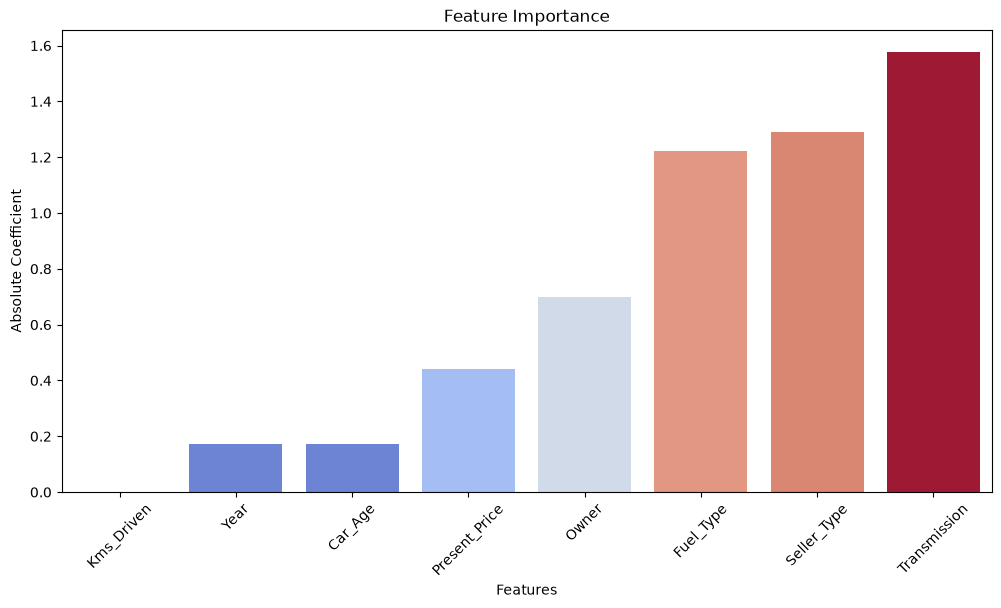

In [103]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=importance.index,
    y=importance.values,
    hue=importance.values,
    palette="coolwarm",
    legend=False
)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=45)

plt.show()